In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.patches as mpatches

In [148]:
# Configurations
mutation_model = {0:"MUTATION_MODEL_SIMPLE_SNP_ONLY",1:"MUTATION_MODEL_GEOMETRIC_MUTATOR"}
mutation_expressions = {0:"BALANCED",1:"SUB_ONLY",2:"DEL_LITE",3:"INS_LITE",4:"SUB_LITE"}

distance_metric = {0:"None",1:"Hamming Similarity",2:"Jaccard Similarity",3:"Cosine Similarity",4:"Angular Similarity",5:"Edit Similarity"}

In [149]:
def read_collision_data_complete(filename):
    
    with open(filename, 'r') as file:
        lines = file.readlines()

    sections = {}
    data_rows = []
    similarity_values = []
    snp_rate = []
    delRate = []
    insmean = []
    insrate = []
    stayRate = []
    rand_base_params = []   # This is equal to snp_rate for sub-only model and equal to g_mean from geo-ins model

    current_AND_param = ""
    current_OR_param = ""
    # Base metadata that applies to all rows
    base_metadata = {}

    for line in lines:
        line = line.strip()
        if not line:
            continue
            
        if line.startswith(':1:'):
            base_metadata['test_name'] = line[3:].strip()
        elif line.startswith(':2:'):
            base_metadata['column_headers'] = line[3:].strip().split(',')
        elif line.startswith(':3:'):
            line_content = line[3:].strip()
            line_parts = line_content.split(',')
            base_metadata['Hashname'] = line_parts[0].strip()
            base_metadata['SequenceLength'] = int(line_parts[1].strip())
            base_metadata['TokenLength'] = int(line_parts[2].strip())
            base_metadata['DistanceMetric'] = int(line_parts[3].strip())
            base_metadata['MutationModel'] = int(line_parts[4].strip())
            base_metadata['MutationExpression'] = int(line_parts[5].strip())
        elif line.startswith(':4:'):  # Specific to subseqhash
            line_content = line[3:].strip()
            line_parts = line_content.split(',')
            base_metadata['SubseqHash_k'] = line_parts[0].strip()
            base_metadata['SubseqHash_d'] = int(line_parts[1].strip())
        elif line.startswith(':5:'):
            line_content = line[3:].strip()
            similarity_values = [float(x.strip()) for x in line_content.split(',')]
        elif line.startswith(':6:'):
            line_content = line[3:].strip()
            snp_rate = [float(x.strip()) for x in line_content.split(',')]
        elif line.startswith(':7:'):
            line_content = line[3:].strip()
            delRate = [float(x.strip()) for x in line_content.split(',')]
        elif line.startswith(':8:'):
            line_content = line[3:].strip()
            insmean = [float(x.strip()) for x in line_content.split(',')]
        elif line.startswith(':9:'):
            line_content = line[3:].strip()
            stayRate = [float(x.strip()) for x in line_content.split(',')]
        elif line.startswith(':10:'):
            # Skip or store if needed
            pass
        elif line.startswith(':11:'):
            line_content = line[4:].strip()
            # Store current AND/OR params for the upcoming :12: line
            amplification_params = line_content.split(',')
            current_AND_param = amplification_params[0]
            current_OR_param = amplification_params[1]
        elif line.startswith(":13:"):
            line_content = line[4:].strip()
            rand_base_params = [float(x.strip()) for x in line_content.split(',')]
        elif line.startswith(":14:"):
            line_content = line[4:].strip()
            insrate = [float(x.strip()) for x in line_content.split(',')]
        elif line.startswith(":12:"):
            line_content = line[4:].strip()
            collision_rates = [float(x.strip()) for x in line_content.split(',')]
            # Create a new data row for this set of collision rates
            row_data = {
                'test_name': base_metadata.get('test_name', ''),
                'hashname': base_metadata.get('Hashname', ''),
                'sequencelength': base_metadata.get('SequenceLength', 0),
                'tokenlength': base_metadata.get('TokenLength', 0),
                'DistanceMetric': base_metadata.get('DistanceMetric', 0),
                'MutationModel': base_metadata.get('MutationModel', 0),
                'MutationExpression': base_metadata.get('MutationExpression', 0),
                'SubseqHash_k': base_metadata.get('SubseqHash_k', 0),
                'SubseqHash_d': base_metadata.get('SubseqHash_d', 0),
                'AND_param': current_AND_param,
                'OR_param': current_OR_param,
                'similarity_values': similarity_values.copy(),
                'snp_rate': snp_rate.copy(),
                'delRate': delRate.copy(),
                'insmean': insmean.copy(),
                'insrate': insrate.copy(),
                'stayRate': stayRate.copy(),
                'collision_rates': collision_rates.copy(),
                'rand_base_params': rand_base_params,
            }
            data_rows.append(row_data)
    
    return sections, pd.DataFrame(data_rows)

In [158]:
# For verification
def plot_histogram(values, title="Histogram", xlabel="Value", ylabel="Count"):
    fig, ax = plt.subplots()

    ax.hist(
        values,
        bins=26,          # required
        alpha=0.85,
        edgecolor="black", # keep if your current style uses outlined bars
        linewidth=0.4
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # keep grid settings if your current style uses them
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    return fig, ax

def plot_distribution_curve_fixed_range_100(
    values,
    ax=None,
    label=None,
    color=None,
    alpha=0.22,      # translucent fill
    bw_method=0.2,   # smoothing control
):
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure

    # keep the fixed domain behavior (0..100)
    v = np.asarray(values, dtype=float)
    v = v[(v >= 0) & (v <= 100)]
    if len(v) < 2:
        return fig, ax  # not enough data for KDE

    x = np.linspace(0, 100, 500)   # fixed x-range, never changes
    kde = gaussian_kde(v, bw_method=bw_method)
    y = kde(x)

    ax.plot(x, y, color=color, linewidth=2, label=label)
    ax.fill_between(x, 0, y, color=color, alpha=alpha)

    ax.set_xlim(0, 100)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.25)
    return fig, ax

def plot_distribution_curve(
    values,
    ax=None,
    label=None,
    color=None,
    alpha=0.22,
    bw_method=0.1,
    linestyle='-',   # Default: solid line
    dashes=None,     # Optional: Tuple for custom spacing (e.g., (5, 5))
    linewidth=2      # Allow changing thickness
):
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure

    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if len(v) < 2:
        return fig, ax

    # Dynamic x-domain logic
    xmin, xmax = v.min(), v.max()
    if xmin == xmax:
        pad = 1e-6
        xmin -= pad
        xmax += pad
    else:
        pad = 0.05 * (xmax - xmin)
        xmin -= pad
        xmax += pad

    x = np.linspace(xmin, xmax, 500)
    kde = gaussian_kde(v, bw_method=bw_method)
    y = kde(x)

    # 1. Create the line object
    (line,) = ax.plot(x, y, color=color, linewidth=linewidth, linestyle=linestyle, label=label)
    
    # 2. Apply custom dashes if provided (overrides linestyle)
    # Format: (offset, (on_len, off_len, ...))
    if dashes:
        line.set_dashes(dashes)

    ax.fill_between(x, 0, y, color=color, alpha=alpha)

    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.25)
    
    return fig, ax

# Average per bin curve
def plot_binned_average_curve(
    row,
    ax=None,
    color=None,
    markersize=6,
    linewidth=1.6,
    alpha=1,
):
    """Add a single bin-averaged collision curve to ax. Returns (fig, ax)."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(16, 8))
    else:
        fig = ax.figure

    x_values = np.array(row['similarity_values'])
    y_values = np.array(row['collision_rates'])

    # Define bins
    bin_edges = np.arange(0, 1.02, 0.02)
    num_bins = len(bin_edges) - 1         
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Compute mean for each bin
    bin_means = []
    for i in range(num_bins):
        mask = (x_values >= bin_edges[i]) & (x_values < bin_edges[i + 1])
        if mask.sum() > 0:
            bin_means.append(np.mean(y_values[mask]))
        else:
            bin_means.append(np.nan)

    bin_means = np.array(bin_means)
    valid = ~np.isnan(bin_means)

    mutation_model_used = ""
    if row['MutationModel'] == 0:
        mutation_model_used = "SUB-ONLY"
    
    if row['MutationModel'] == 1:
        mutation_model_used = "GEO-" + mutation_expressions[row["MutationExpression"]]

    # Build label
    if row['AND_param'] == '1' and row['OR_param'] == '1':
        if row['hashname'] == "SubseqHash-64":
            label = f"SubseqHash (L={row['sequencelength']}, k={row['SubseqHash_k']}, d={row['SubseqHash_d']})[{mutation_model_used}]"
        else:
            label = f"{row['hashname']} (L={row['sequencelength']}, k={row['tokenlength']})[{mutation_model_used}]"
    else:
        if row['hashname'] == "SubseqHash-64":
            label = f"SubseqHash (L={row['sequencelength']}, k={row['SubseqHash_k']}, d={row['SubseqHash_d']}, AND={row['AND_param']}, OR={row['OR_param']})[{mutation_model_used}]"
        else:
            label = f"{row['hashname']} (L={row['sequencelength']}, k={row['tokenlength']}, AND={row['AND_param']}, OR={row['OR_param']})[{mutation_model_used}]"

    ax.plot(
        bin_centers[valid],
        bin_means[valid],
        '-o',
        color=color,
        alpha=alpha,
        markersize=markersize,
        linewidth=linewidth,
        label=label,
    )

    return fig, ax

def finalize_binned_average_plot(
    ax,
    similarity_label="Similarity",
    s1=None,
    s2=None,
    savename=None,
):
    """Add ideal line, vertical markers, grid, legend, and optionally save."""
    ax.plot([0, 1], [0, 1], color="black", linewidth=1, alpha=1, label="Similarity estimator")

    if s1 is not None:
        ax.axvline(x=s1, color='black', label=f'$s_1 = {s1}$', linewidth=1.2, linestyle='dashed')
    if s2 is not None:
        ax.axvline(x=s2, color='black', label=f'$s_2 = {s2}$', linewidth=1.2, linestyle='dashed')

    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.01, 1.01)
    ax.minorticks_on()
    ax.grid(visible=True, which="both", axis="both", alpha=0.5)
    ax.set_xlabel(similarity_label, fontsize=12)
    ax.set_ylabel('Average Collision Rate', fontsize=12)
    ax.legend(fontsize=15)
    ax.figure.tight_layout()

    if savename:
        ax.figure.savefig(savename, dpi=600, bbox_inches='tight')

# Color Scatter Plot for Subs-Only Model
def plot_color_scatter(
    df, 
    n_cols=2, 
    xlabel="Similarity", 
    save_filename=None,
    show_plot=True
):
    """
    Generates a grid of scatter plots for hash collision rates vs similarity.
    
    Parameters:
    - df: DataFrame containing the data. Must contain columns:
          'similarity_values', 'collision_rates', 'snp_rate', 'hashname', 
          'sequencelength', 'tokenlength', and optionally 'SubseqHash_k', 'SubseqHash_d'.
    - n_cols: Number of columns in the subplot grid.
    - xlabel: Label for the X-axis (variable 'similarity' in original snippet).
    - save_filename: If provided, saves the figure to this path (e.g., "my_plot"). 
                     Suffixes like _snpcolor_multiplot.png will be appended automatically 
                     if you want to match the original style, or provide the full name.
    """
    
    n_rows = len(df)
    # Calculate required grid rows
    n_grid_rows = (n_rows + n_cols - 1) // n_cols 
    
    # Create figure
    # Note: Adjust figsize calculation if you want a fixed size rather than dynamic
    fig, axes = plt.subplots(nrows=n_grid_rows, ncols=n_cols, figsize=(28, 7 * n_grid_rows))
    
    # Flatten axes for easy 1D iteration. 
    # Handle edge case where n_rows=1 (subplots returns a single Axes object, not array)
    if n_rows == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    # Iterate using enumerate to get a safe 0-based index 'i' for axes
    for i, (idx, row) in enumerate(df.iterrows()):
        ax = axes[i]
        
        # Extract data (assuming cells contain lists/arrays)
        x_values = np.array(row['similarity_values'])
        y_values = np.array(row['collision_rates'])
        label_values = np.array(row['snp_rate'])
        
        # Determine Label based on hashname
        hash_name = row.get('hashname', 'Unknown')
        seq_len = row.get('sequencelength', '?')
        
        if hash_name == "SubseqHash-64":
            k_val = row.get('SubseqHash_k', '?')
            d_val = row.get('SubseqHash_d', '?')
            label = f"SubseqHash (L={seq_len}, k={k_val}, d={d_val})"
        else:
            token_len = row.get('tokenlength', '?')
            label = f"{hash_name} (L={seq_len}, k={token_len})"
            
        # Scatter plot with colorbar
        scatter = ax.scatter(x_values, y_values, c=label_values, cmap='viridis', 
                             alpha=0.3, edgecolors='black', linewidth=0.3, s=25)
        
        # Add colorbar for each subplot
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('SNP Rate', fontsize=14)
        
        # Axis settings
        ax.set_xlim(0, 1.02)
        ax.set_ylim(0, 1.02)
        ax.set_xlabel(xlabel, fontsize=22)
        ax.set_ylabel('Collision Rates', fontsize=22)
        ax.grid(True, alpha=0.5)
        
        # Legend (using the generated label)
        # We pass [scatter] to legend to ensure the label is associated with the points, 
        # though ax.legend([label]) works, passing the handle is cleaner.
        ax.legend(handles=[scatter], labels=[label], loc='upper left', fontsize=18)
        ax.tick_params(axis='both', labelsize=14)

    # Hide unused subplots (if n_rows < total grid slots)
    for j in range(n_rows, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    
    # name = f"{row['hashname']}"
    # plt.savefig(f"{name}_snpcolor_multiplot.png", dpi=600)
    
    # Save logic
    if save_filename:
        # If user didn't provide an extension, add the style from the original snippet
        if not save_filename.endswith('.png'):
            final_name = f"{save_filename}_snpcolor_multiplot.png"
        else:
            final_name = save_filename
            
        plt.savefig(final_name, dpi=600)
        print(f"Plot saved to {final_name}")
    
    if show_plot:
        plt.show()

# BOX PLOT per bin
def plot_hash_collision_boxplots(
    df, 
    n_cols=2, 
    xlabel="Similarity", 
    save_filename=None,
    num_bins=21,
    show_plot=True
):
    """
    Generates a grid of box plots for hash collision rates binned by similarity.
    
    Parameters:
    - df: DataFrame containing 'similarity_values', 'collision_rates', and metadata columns.
    - n_cols: Number of columns in the subplot grid.
    - xlabel: Label for the X-axis (variable 'similarity' in original snippet).
    - save_filename: If provided, saves the figure.
    - num_bins: Number of bins to divide the similarity score (0 to 1).
    """
    
    n_rows = len(df)
    n_grid_rows = (n_rows + n_cols - 1) // n_cols 

    # Create figure with dynamic height
    fig, axes = plt.subplots(nrows=n_grid_rows, ncols=n_cols, figsize=(28, 7 * n_grid_rows))
    
    # Handle edge case where n_rows=1 (subplots returns single Axes, not array)
    if n_rows == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    # Define bins
    # Note: bin_edges has num_bins+1 points. 
    # The original logic used `int(sim_value * num_bins)` effectively mapping [0,1] to indices 0..num_bins-1
    bin_edges = np.linspace(0, 1.05, num_bins + 1)

    for i, (idx, row) in enumerate(df.iterrows()):
        ax = axes[i]
        
        # Extract data
        x_values = np.array(row['similarity_values'])
        y_values = np.array(row['collision_rates'])
        
        # --- Label Generation Logic ---
        hash_name = row.get('hashname', 'Unknown')
        seq_len = row.get('sequencelength', '?')
        and_param = str(row.get('AND_param', '?'))
        or_param = str(row.get('OR_param', '?'))
        
        # Determine if we show AND/OR params
        show_params = not (and_param == '1' and or_param == '1')
        
        if hash_name == "SubseqHash-64":
            k_val = row.get('SubseqHash_k', '?')
            d_val = row.get('SubseqHash_d', '?')
            base_label = f"SubseqHash (L={seq_len}, k={k_val}, d={d_val}"
        else:
            token_len = row.get('tokenlength', '?')
            base_label = f"{hash_name} (L={seq_len}, k={token_len}"

        if show_params:
            label = f"{base_label}, AND={and_param}, OR={or_param})"
        else:
            label = f"{base_label})"

        # --- Binning Logic ---
        # Create empty lists for each bin
        binned_collision_rates = [[] for _ in range(num_bins)]
        
        for j in range(len(x_values)):
            sim_value = x_values[j]
            collision_value = y_values[j]
            
            # Map similarity 0.0-1.0 to bin index
            bin_idx = int(sim_value * num_bins)
            if bin_idx >= num_bins:
                bin_idx = num_bins - 1
            
            binned_collision_rates[bin_idx].append(collision_value)
        
        # Filter empty bins for plotting
        plot_data = []
        valid_positions = []
        valid_tick_labels = [] # To store labels for x-axis
        
        for k, bin_data in enumerate(binned_collision_rates):
            if len(bin_data) > 0:
                plot_data.append(bin_data)
                # Position is 1-based index corresponding to bin index
                valid_positions.append(k + 1)
                valid_tick_labels.append(f"{bin_edges[k]:.1f}")

        # --- Plotting ---
        bp = ax.boxplot(
            plot_data,
            positions=valid_positions, # Place boxes at specific x-coordinates
            widths=0.5,
            patch_artist=True,
            showfliers=False
        )
        
        # Style the boxes
        for box in bp['boxes']:
            box.set(facecolor='#C4C4C4', alpha=1, edgecolor='black', linewidth=1)
        for median in bp['medians']:
            median.set(color='black', linewidth=1.5)
        for whisker in bp['whiskers']:
            whisker.set(color='black', linewidth=1)
        for cap in bp['caps']:
            cap.set(color='black', linewidth=1)
        
        # Create custom legend patch
        box_patch = mpatches.Patch(facecolor='#C4C4C4', edgecolor='black', alpha=1, label=label)
        
        # Axis settings
        ax.set_xlim(0.5, num_bins + 0.5)
        ax.set_ylim(0, 1.1)
        ax.set_xlabel(xlabel, fontsize=22)
        ax.set_ylabel('Collision Rates', fontsize=22)
        ax.grid(True, alpha=0.5, axis='y')
        
        # Legend
        ax.legend(handles=[box_patch], loc='upper left', fontsize=18)
        
        # --- X-Ticks Logic ---
        # The original code set ticks at specific valid_positions if (pos-1) % 5 == 0.
        # This aligns ticks to the bin edges 0.0, 0.25, 0.5 etc depending on num_bins.
        tick_pos_to_show = [p for p in valid_positions if (p - 1) % 5 == 0]
        
        # We need to map these positions back to the bin_edges value
        # valid_positions contains 'k+1', so index is 'p-1'
        tick_labels_to_show = [f"{bin_edges[p-1]:.1f}" for p in tick_pos_to_show]
        
        ax.set_xticks(tick_pos_to_show)
        ax.set_xticklabels(tick_labels_to_show, fontsize=14)
        ax.tick_params(axis='y', labelsize=14)

    # Hide unused subplots
    for j in range(n_rows, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    
    # Save logic
    if save_filename:
        if not save_filename.endswith('.png'):
            final_name = f"{save_filename}_boxplot_multiplot.png"
        else:
            final_name = save_filename
            
        plt.savefig(final_name, dpi=600)
        print(f"Plot saved to {final_name}")
    
    if show_plot:
        plt.show()


In [165]:
# sections,df =  read_collision_data_complete("/home/dynamics/bikram/BioHasher/results/collisionResults_SimHash-Ang-32.csv")
# similarity = "Angular Similarity"
# sections,df =  read_collision_data_complete("/home/dynamics/bikram/BioHasher/results/backupresults/collisionResults_OneBaseSamplingHash-32.csv")
# similarity = "Hamming Similarity"
# sections,df =  read_collision_data_complete("/home/dynamics/bikram/BioHasher/results/collisionResults_MinHash-32.csv")
# similarity = "Jaccard Similarity"
sections,df =  read_collision_data_complete("/home/dynamics/bikram/BioHasher/results/collisionResults_SubseqHash-64.csv")
similarity = "Edit Similarity"
# df = df[df['SubseqHash_d'] != 11].reset_index(drop=True)

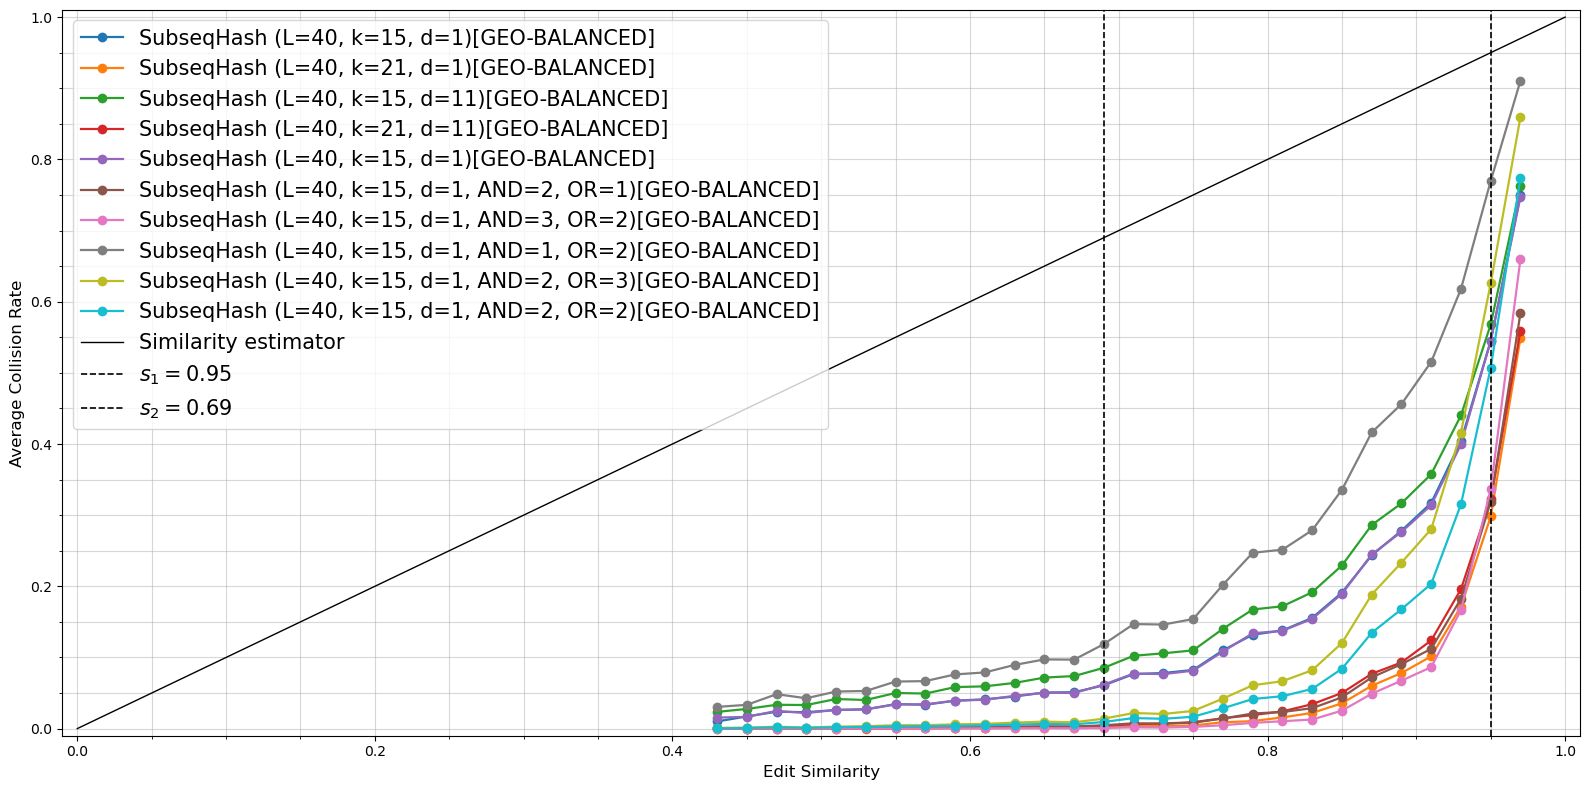

In [166]:
fig, ax = plt.subplots(figsize=(16, 8))

# Add curves one at a time (e.g. from different dataframes / files)
for idx, row in df.iterrows():
    plot_binned_average_curve(row, ax=ax)

# Or add a single row from another dataframe
# plot_binned_average_curve(df2.iloc[0], ax=ax, color="#FF6B6B")

# Finalize: ideal line, grid, legend, save
finalize_binned_average_plot(ax, similarity_label=similarity, s1=0.95, s2=0.69, savename=f"{df.iloc[0]['hashname']}_binaveraged.png")
plt.show()

## Verification

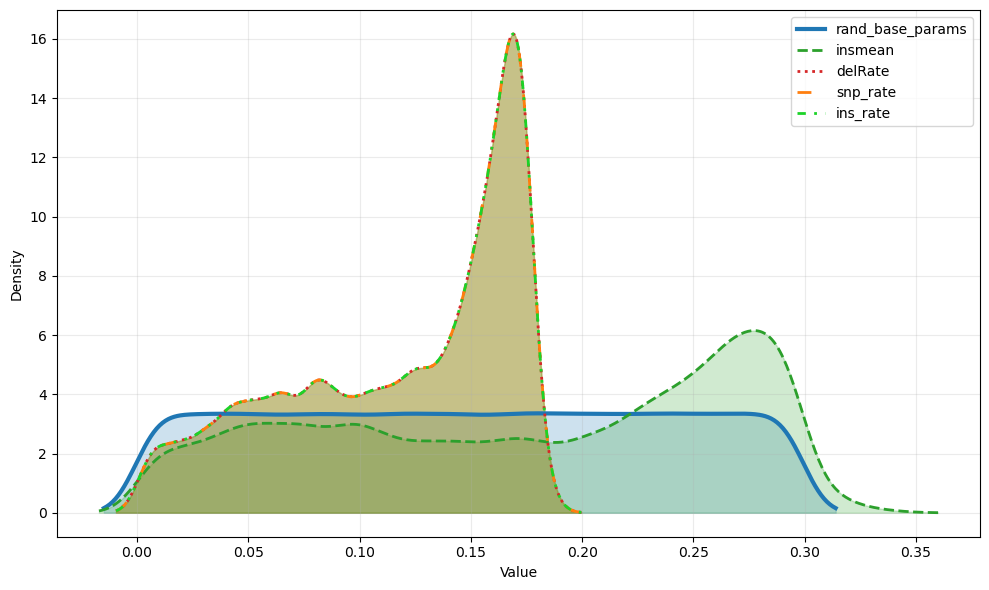

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
row_to_plot = df.iloc[1]

# Curve 1: Thick Solid Line (The "Base")
plot_distribution_curve(
    row_to_plot.rand_base_params, 
    ax=ax, 
    label="rand_base_params", 
    color="#1f77b4",
    linewidth=3, 
    linestyle='-'
)

# Curve 2: Standard Dashed
plot_distribution_curve(
    row_to_plot.insmean, 
    ax=ax, 
    label="insmean", 
    color="#2ca02c", 
    linestyle='--'
)

# Curve 3: Dotted (Dense dots)
plot_distribution_curve(
    row_to_plot.delRate, 
    ax=ax, 
    label="delRate", 
    color="#d62728", 
    linestyle=':'
)

# Curve 4: Custom "Loose" Dashes (Distinguishes from standard dashed)
# (5, 10) means: 5 points ink, 10 points space
plot_distribution_curve(
    row_to_plot.snp_rate, 
    ax=ax, 
    label="snp_rate", 
    color="#ff7f0e", 
    dashes=(5, 10) 
)

# Curve 5: Custom Dash-Dot-Dot (Very distinct pattern)
# (3, 3, 1, 3, 1, 3) means: 3 on, 3 off, 1 on, 3 off, 1 on, 3 off...
plot_distribution_curve(
    row_to_plot.insrate, 
    ax=ax, 
    label="ins_rate", 
    color="#1cd328", 
    dashes=(3, 3, 1, 3, 1, 3)
)

ax.legend()
plt.tight_layout()
plt.show()

## Average per bin

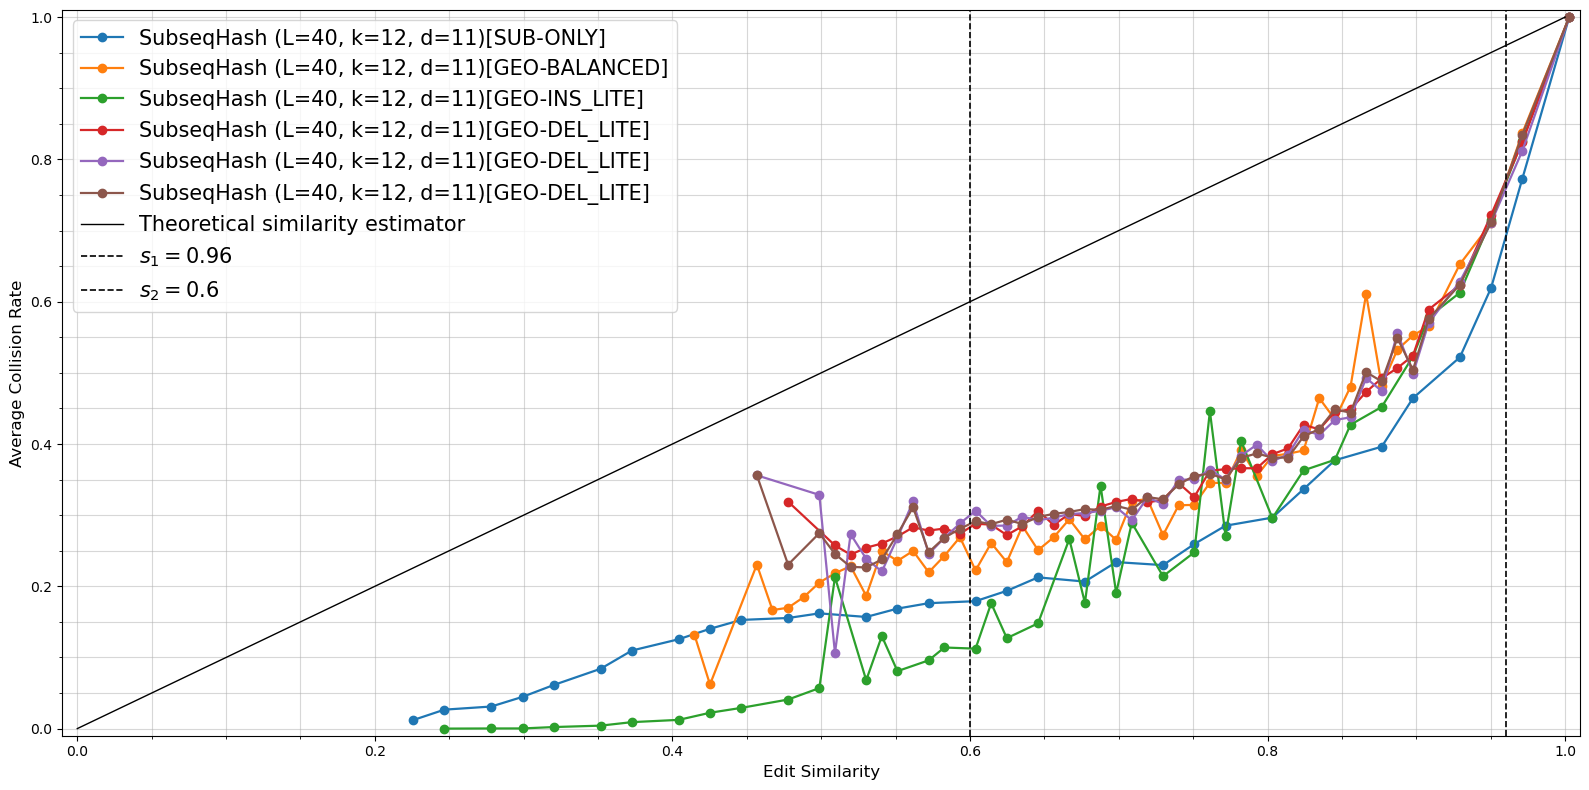

## Color Scatter Plot for Subs-Only Model

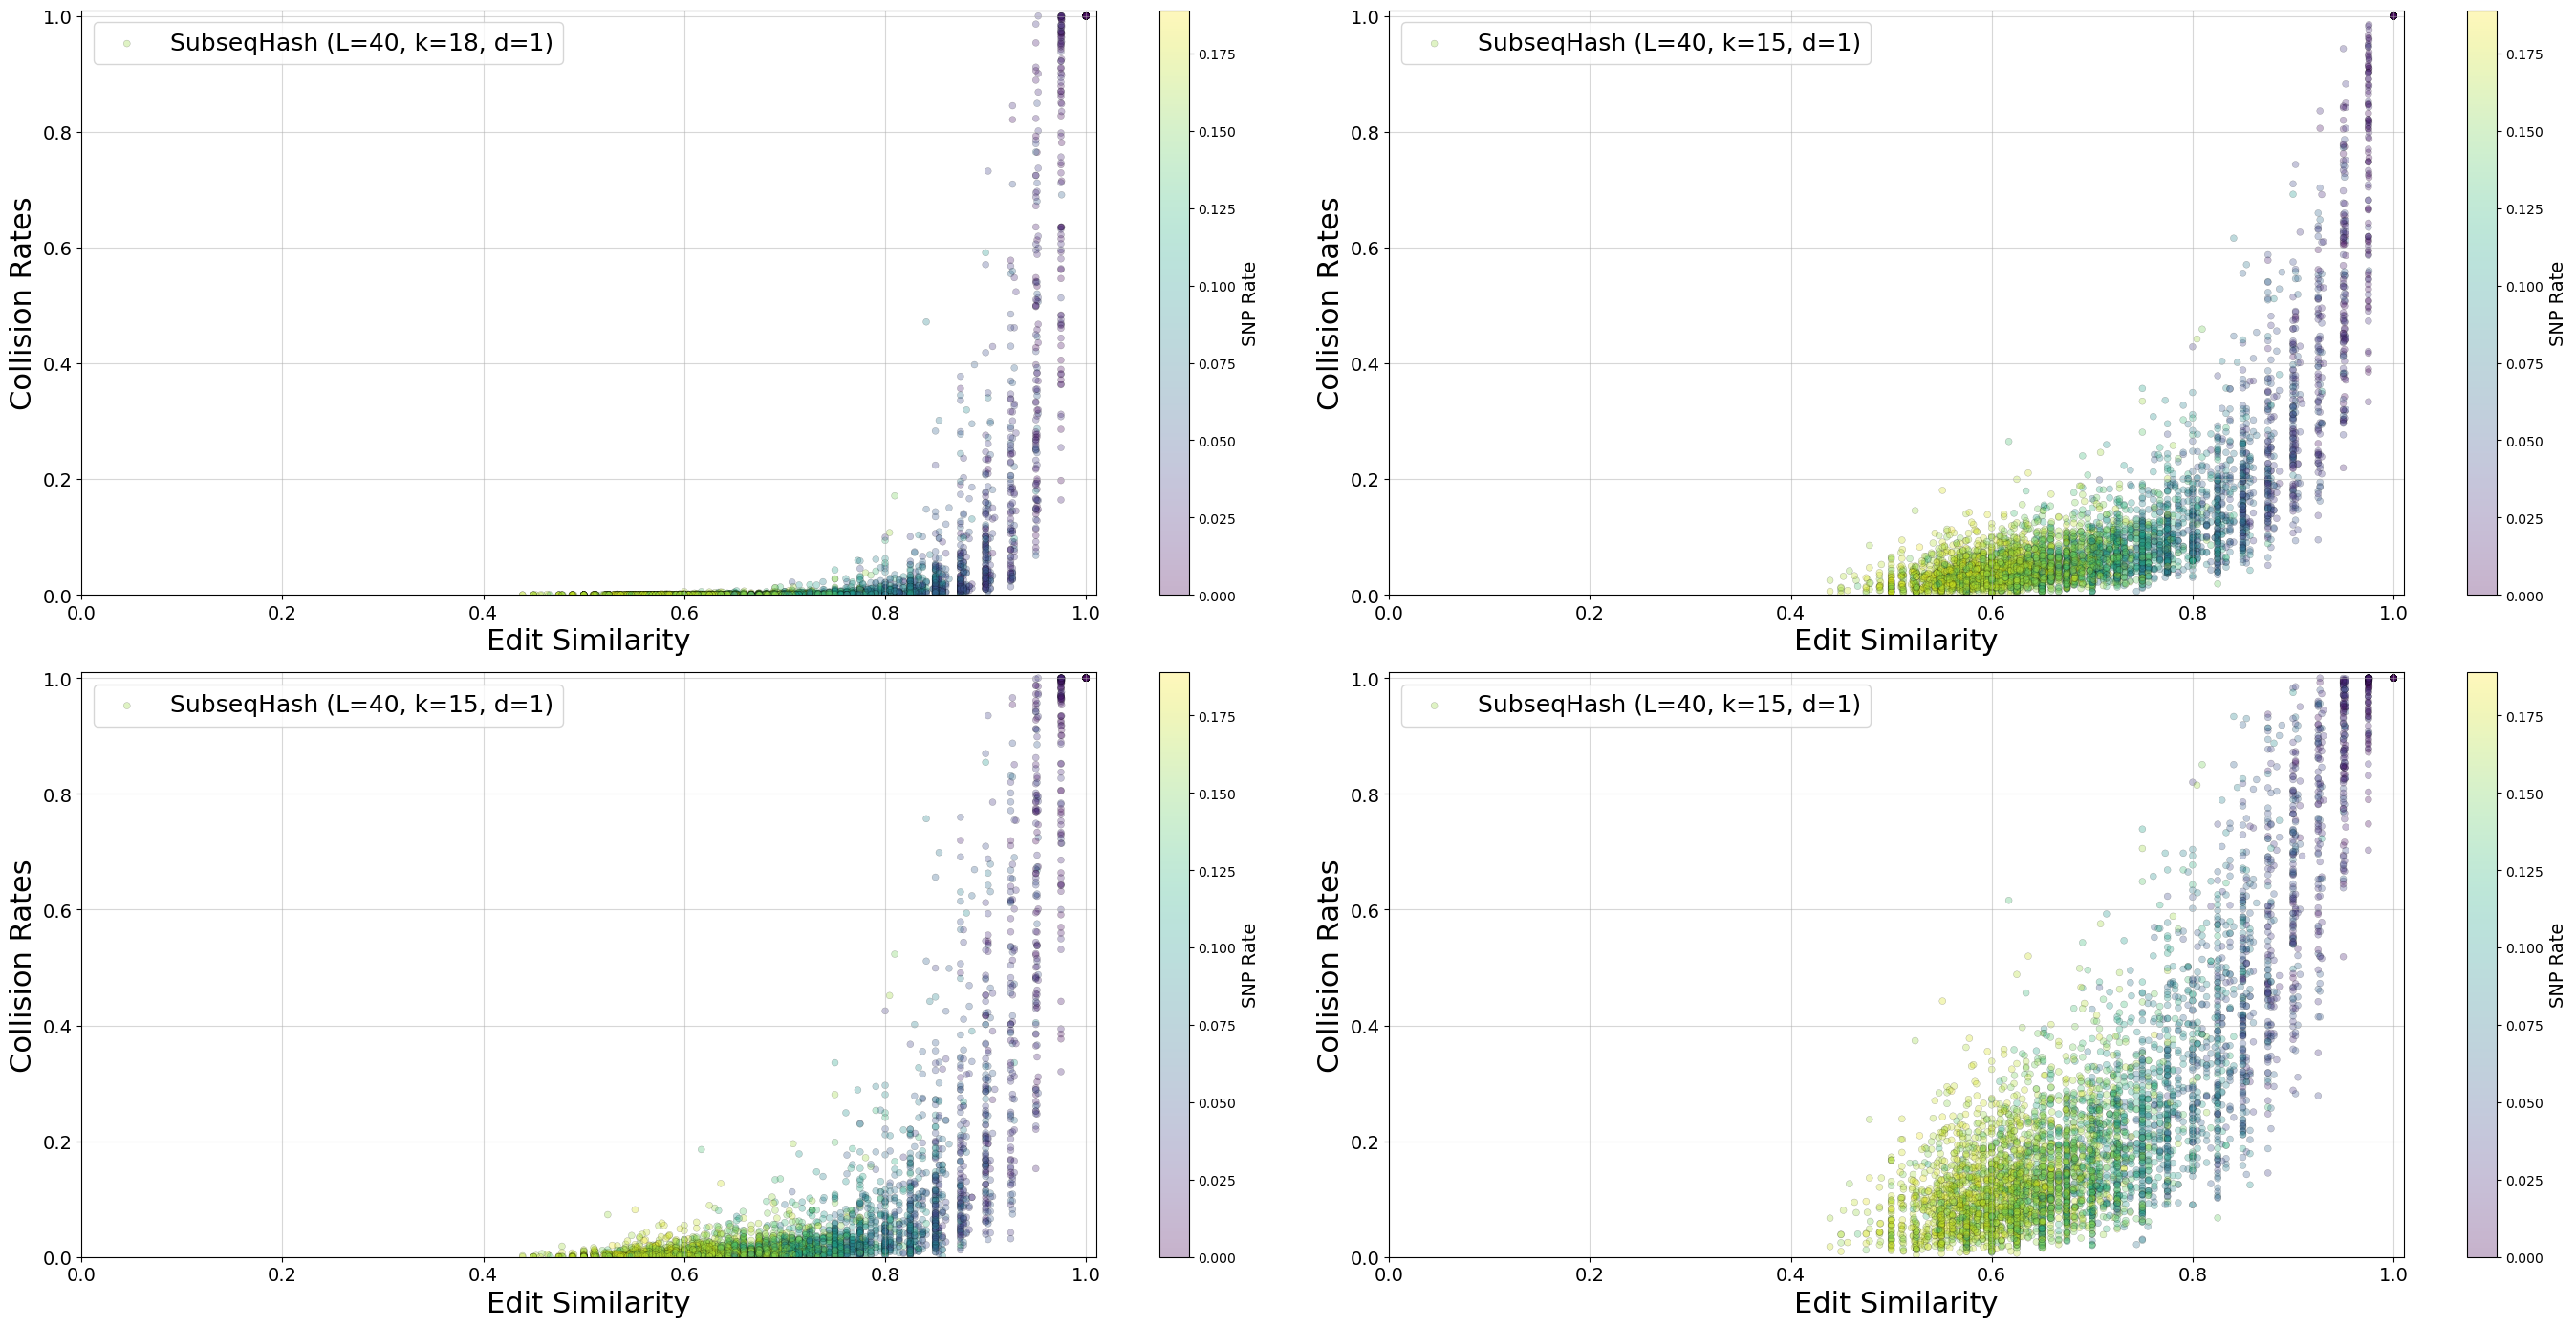

In [63]:
plot_color_scatter(df,xlabel=similarity)

## Box plot

In [ ]:
plot_hash_collision_boxplots(df, xlabel= similarity)

In [ ]:
df = df.drop([1,2,3,5,8]).reset_index(drop=True)
df.loc[[1, 3]] = df.loc[[3, 1]].values
df.loc[[3, 4]] = df.loc[[4, 3]].values
df.loc[[2, 3]] = df.loc[[3, 2]].values
df

## Color Scatter Plot for Subs-Only Model

In [ ]:
n_rows = len(df)
n_cols = 2
n_grid_rows = (n_rows + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(nrows=n_grid_rows, ncols=n_cols, figsize=(28, 7 * n_grid_rows))
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for idx, row in df.iterrows():
    ax = axes[idx]
    
    x_values = np.array(row['similarity_values'])
    y_values = np.array(row['collision_rates'])
    label_values = np.array(row['snp_rate'])
    
    if(row['hashname'] == "SubseqHash-64"):
        label = f"SubseqHash (L={row['sequencelength']}, k={row['SubseqHash_k']}, d={row['SubseqHash_d']})"
    else:
        label = f"{row['hashname']} (L={row['sequencelength']},k={row['tokenlength']})"
        
    
    # Scatter plot with colorbar
    scatter = ax.scatter(x_values, y_values, c=label_values, cmap='viridis', 
                         alpha=0.3, edgecolors='black', linewidth=0.3, s=25)
    
    # Add colorbar for each subplot
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('SNP Rate', fontsize=14)
    
    # Ideal line
    # ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Ideal')
    
    # Axis settings
    ax.set_xlim(0, 1.01)
    ax.set_ylim(0, 1.01)
    ax.set_xlabel(similarity, fontsize=22)
    ax.set_ylabel('Collision Rates', fontsize=22)
    ax.grid(True, alpha=0.5)
    ax.legend([label], loc='upper left', fontsize=18)
    ax.tick_params(axis='both', labelsize=14)

# Hide unused subplots
for idx in range(len(df), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
name = f"{row['hashname']}"
plt.savefig(f"{name}_snpcolor_multiplot.png", dpi=600)
plt.show()

## Average Line Plot for collision Curve

In [ ]:
# Define colors for different rows
# colors = ['#FF6B6B', '#4ECDC4', '#FFA07A', '#9B59B6', '#3498DB', '#2ECC71', '#E74C3C', '#1ABC9C']

# Create single figure
plt.figure(figsize=(16, 8))


name =""

for idx, row in df.iterrows():
    x_values = np.array(row['similarity_values'])
    y_values = np.array(row['collision_rates'])
    
    # Define bins: 100 bins covering [0.00, 1.00]
    bin_edges = np.arange(0, 1.02, 0.01)   # [0.00, 0.01, ..., 1.00]
    num_bins = len(bin_edges) - 1            # 100 bins
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # 0.005, 0.015, ..., 0.995
    
    # Compute mean for each bin
    bin_means = []
    
    for i in range(num_bins):
        if i == num_bins - 1:
            # Last bin is inclusive on both sides: [0.99, 1.00]
            mask = (x_values >= bin_edges[i]) & (x_values <= bin_edges[i + 1])
        else:
            mask = (x_values >= bin_edges[i]) & (x_values < bin_edges[i + 1])
        
        if mask.sum() > 0:
            bin_means.append(np.mean(y_values[mask]))
        else:
            bin_means.append(np.nan)
        
    
    bin_means = np.array(bin_means)
    valid = ~np.isnan(bin_means)
    
    label = ""
    if(row['AND_param'] == '1' and row['OR_param']=='1'):
        # Create label from row data with AND/OR values
        if(row['hashname'] == "SubseqHash-64"):
            label = f"{"SubseqHash"} (L={row['sequencelength']}, k={row['SubseqHash_k']}, d={row['SubseqHash_d']})"
        else:
            label = f"{row['hashname']} (L={row['sequencelength']}, k={row['tokenlength']})"
    else:
        # Create label from row data with AND/OR values
        if(row['hashname'] == "SubseqHash-64"):
            label = f"{"SubseqHash"} (L={row['sequencelength']}, k={row['SubseqHash_k']}, d={row['SubseqHash_d']}, AND={row['AND_param']}, OR={row['OR_param']})"
        else:
            label = f"{row['hashname']} (L={row['sequencelength']}, k={row['tokenlength']}, AND={row['AND_param']}, OR={row['OR_param']})"
            
    name = f"{row['hashname']}"
    
    # Plot this row with unique color
    plt.plot(
        bin_centers[valid],
        bin_means[valid],
        '-o',
        # color=colors[idx % len(colors)],
        alpha=1,
        markersize=6,
        linewidth=1.6,
        label=label
    )

# Ideal line
plt.plot([0, 1], [0, 1], color="black", linewidth=1, alpha=1, label="Theoretical similarity estimator")

plt.axvline(x = 0.96, color = 'black', label = '$s_1 = 0.96$', linewidth = 1.2,linestyle='dashed')
plt.axvline(x = 0.60, color = 'black', label = '$s_2 = 0.60$', linewidth = 1.2,linestyle='dashed')

# Styling
plt.xlim(-0.01, 1.02)
plt.ylim(-0.01, 1.02)
plt.minorticks_on()
plt.grid(visible=True, which="both", axis="both", alpha=0.5)
plt.xlabel(similarity, fontsize=12)
plt.ylabel('Average Collision Rate', fontsize=12)

# Legend outside the plot (to the right)
plt.legend(fontsize=15)

plt.tight_layout()

plt.savefig(f"{name}_binaveraged.png", dpi=600, bbox_inches='tight')
plt.show()

ValueError: operands could not be broadcast together with shapes (0,) (102,) 

<Figure size 1600x800 with 0 Axes>

## Average Line plot with s1,s2 and p1,p2 

In [ ]:
# # Define distinct line styles and markers for black & white theme
# line_styles = ['-', '--', '-.', ':', '-', '--', '-.', ':']
# markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']

# # Create single figure
# plt.figure(figsize=(16, 7))

# # Define s1 and s2 (ensure s1 >= s2)
# s1 = 0.8  # Higher similarity value
# s2 = 0.4  # Lower similarity value

# # Ensure s1 >= s2
# if s1 < s2:
#     s1, s2 = s2, s1

# name = ""
# intersection_points = []  # Store (s, p) pairs for each curve

# for plot_idx, (idx, row) in enumerate(df.iterrows()):
#     x_values = np.array(row['similarity_values'])
#     y_values = np.array(row['collision_rates'])
    
#     # Define bins
#     num_bins = 100
#     bin_edges = np.linspace(0, 1.05, num_bins + 1)
#     bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
#     # Compute mean for each bin
#     bin_means = []
    
#     for i in range(num_bins):
#         mask = (x_values >= bin_edges[i]) & (x_values < bin_edges[i + 1])
#         if mask.sum() > 0:
#             bin_means.append(np.mean(y_values[mask]))
#         else:
#             bin_means.append(np.nan)
    
#     bin_means = np.array(bin_means)
#     valid = ~np.isnan(bin_means)
    
#     # Get valid bin centers and mins for finding intersection
#     valid_centers = bin_centers[valid]
#     valid_means = bin_means[valid]
    
#     # Find p1: closest bin center to s1 (no interpolation)
#     idx_s1 = np.argmin(np.abs(valid_centers - s1))
#     p1 = valid_means[idx_s1]
#     actual_s1 = valid_centers[idx_s1]
    
#     # Find p2: closest bin center to s2 (no interpolation)
#     idx_s2 = np.argmin(np.abs(valid_centers - s2))
#     p2 = valid_means[idx_s2]
#     actual_s2 = valid_centers[idx_s2]
    
#     intersection_points.append({
#         'label': row['hashname'],
#         's1': actual_s1, 'p1': p1,
#         's2': actual_s2, 'p2': p2
#     })
    
#     # Create label from row data with AND/OR values
#     if row['hashname'] == "SubseqHash-64":
#         label = f"SubseqHash (L={row['sequencelength']}, k={row['SubseqHash_k']}, d={row['SubseqHash_d']}, AND={row['AND_param']}, OR={row['OR_param']})"
#     else:
#         label = f"{row['hashname']} (L={row['sequencelength']}, k={row['tokenlength']}, AND={row['AND_param']}, OR={row['OR_param']})"
        
#     name = f"{row['hashname']}"
    
#     # Plot this row with distinct line style and marker (all in black/gray)
#     plt.plot(
#         bin_centers[valid],
#         bin_means[valid],
#         linestyle=line_styles[plot_idx % len(line_styles)],
#         marker=markers[plot_idx % len(markers)],
#         color='black',
#         alpha=1,
#         markersize=5,
#         linewidth=1.5,
#         markerfacecolor='none',
#         markeredgewidth=1,
#         markevery=1,
#         label=label
#     )
    
#     # Mark intersection points on the curve
#     plt.scatter([actual_s1], [p1], s=120, zorder=5, marker='x', color='black', linewidths=2.5)
#     plt.scatter([actual_s2], [p2], s=120, zorder=5, marker='x', color='black', linewidths=2.5)

# # Add vertical lines at s1 and s2
# plt.axvline(x=s1, color='black', linestyle='--', linewidth=1.2, alpha=0.6, label=f's1 = {s1}')
# plt.axvline(x=s2, color='black', linestyle=':', linewidth=1.2, alpha=0.6, label=f's2 = {s2}')

# # Ideal line
# plt.plot([0, 1], [0, 1], color='gray', linewidth=1.2, alpha=0.7, linestyle='-', label="Theoretical similarity estimator")

# # Styling
# plt.xlim(-0.01, 1.01)
# plt.ylim(-0.01, 1.01)
# plt.grid(visible=True, which="both", axis="both", alpha=0.3, color='gray', linestyle=':')
# plt.xlabel(similarity, fontsize=12)
# plt.ylabel('Minimum Collision Rate', fontsize=12)

# # Legend
# plt.legend(fontsize=10)

# plt.tight_layout()

# plt.savefig(f"{name}_binmin.png", dpi=600, bbox_inches='tight')
# plt.show()

# # Print intersection points
# print("\nIntersection Points (from data, no interpolation):")
# for pt in intersection_points:
#     print(f"{pt['label']}: s1={pt['s1']:.4f} -> p1={pt['p1']:.4f}, s2={pt['s2']:.4f} -> p2={pt['p2']:.4f}")

In [ ]:
# Define colors for different rows
# colors = ['#FF6B6B', '#4ECDC4', '#FFA07A', '#9B59B6', '#3498DB', '#2ECC71', '#E74C3C', '#1ABC9C']

# Create single figure
plt.figure(figsize=(16, 6))


name =""

for idx, row in df.iterrows():
    x_values = np.array(row['similarity_values'])
    y_values = np.array(row['collision_rates'])
    
    # Define bins
    num_bins = 100
    bin_edges = np.linspace(0, 1.05, num_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Compute minimum for each bin
    bin_mins = []
    
    for i in range(num_bins):
        mask = (x_values >= bin_edges[i]) & (x_values < bin_edges[i + 1])
        if mask.sum() > 0:
            bin_mins.append(np.min(y_values[mask]))
        else:
            bin_mins.append(np.nan)
    
    bin_mins = np.array(bin_mins)
    valid = ~np.isnan(bin_mins)
    
    # Create label from row data with AND/OR values
    if(row['hashname'] == "SubseqHash-64"):
        label = f"{row['hashname']} (L={row['sequencelength']}, k={row['SubseqHash_k']}, d={row['SubseqHash_d']}, AND={row['AND_param']}, OR={row['OR_param']})"
    else:
        label = f"{row['hashname']} (L={row['sequencelength']}, k={row['tokenlength']}, AND={row['AND_param']}, OR={row['OR_param']})"
        
    name = f"{row['hashname']}"
    
    # Plot this row with unique color
    plt.plot(
        bin_centers[valid],
        bin_mins[valid],
        '-o',
        # color=colors[idx % len(colors)],
        alpha=1,
        markersize=6,
        linewidth=2,
        label=label
    )

# Ideal line
plt.plot([0, 1], [0, 1], color="black", linewidth=1.5, alpha=1, label="Theoretical full-lsh")

# Styling
plt.xlim(-0.01, 1.01)
plt.ylim(-0.01, 1.01)
plt.grid(visible=True, which="both", axis="both", alpha=0.5)
plt.xlabel(similarity, fontsize=12)
plt.ylabel('Minimum Collision Rate', fontsize=12)

# Legend outside the plot (to the right)
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10)

plt.tight_layout()

plt.savefig(f"{name}_binmin.png", dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
# Define colors for different rows
# colors = ['#FF6B6B', '#4ECDC4', '#FFA07A', '#9B59B6', '#3498DB', '#2ECC71', '#E74C3C', '#1ABC9C']

# Create single figure
plt.figure(figsize=(16, 6))

# Define s1 and s2 (ensure s1 >= s2)
s1 = 0.8  # Higher similarity value
s2 = 0.4  # Lower similarity value

# Ensure s1 >= s2
if s1 < s2:
    s1, s2 = s2, s1

name = ""
intersection_points = []  # Store (s, p) pairs for each curve

for idx, row in df.iterrows():
    x_values = np.array(row['similarity_values'])
    y_values = np.array(row['collision_rates'])
    
    # Define bins
    num_bins = 100
    bin_edges = np.linspace(0, 1.05, num_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Compute minimum for each bin
    bin_mins = []
    
    for i in range(num_bins):
        mask = (x_values >= bin_edges[i]) & (x_values < bin_edges[i + 1])
        if mask.sum() > 0:
            bin_mins.append(np.min(y_values[mask]))
        else:
            bin_mins.append(np.nan)
    
    bin_mins = np.array(bin_mins)
    valid = ~np.isnan(bin_mins)
    
    # Get valid bin centers and mins for finding intersection
    valid_centers = bin_centers[valid]
    valid_mins = bin_mins[valid]
    
    # Find p1: closest bin center to s1 (no interpolation)
    idx_s1 = np.argmin(np.abs(valid_centers - s1))
    p1 = valid_mins[idx_s1]
    actual_s1 = valid_centers[idx_s1]
    
    # Find p2: closest bin center to s2 (no interpolation)
    idx_s2 = np.argmin(np.abs(valid_centers - s2))
    p2 = valid_mins[idx_s2]
    actual_s2 = valid_centers[idx_s2]
    
    intersection_points.append({
        'label': row['hashname'],
        's1': actual_s1, 'p1': p1,
        's2': actual_s2, 'p2': p2
    })
    
    # Create label from row data with AND/OR values
    if row['hashname'] == "SubseqHash-64":
        label = f"{row['hashname']} (L={row['sequencelength']}, k={row['SubseqHash_k']}, d={row['SubseqHash_d']}, AND={row['AND_param']}, OR={row['OR_param']})"
    else:
        label = f"{row['hashname']} (L={row['sequencelength']}, k={row['tokenlength']}, AND={row['AND_param']}, OR={row['OR_param']})"
        
    name = f"{row['hashname']}"
    
    # Plot this row with unique color
    plt.plot(
        bin_centers[valid],
        bin_mins[valid],
        '-o',
        alpha=1,
        markersize=6,
        linewidth=2,
        label=label
    )
    
    # Mark intersection points on the curve
    plt.scatter([actual_s1], [p1], s=100, zorder=5, edgecolors='black', linewidth=2)
    plt.scatter([actual_s2], [p2], s=100, zorder=5, edgecolors='black', linewidth=2)

# Add vertical lines at s1 and s2
plt.axvline(x=s1, color='red', linestyle='--', linewidth=1.5, label=f's1 = {s1}')
plt.axvline(x=s2, color='blue', linestyle='--', linewidth=1.5, label=f's2 = {s2}')

# Ideal line
plt.plot([0, 1], [0, 1], color="black", linewidth=1.5, alpha=1, label="Theoretical full-lsh")

# Styling
plt.xlim(-0.01, 1.01)
plt.ylim(-0.01, 1.01)
plt.grid(visible=True, which="both", axis="both", alpha=0.5)
plt.xlabel(similarity, fontsize=12)
plt.ylabel('Minimum Collision Rate', fontsize=12)

# Legend outside the plot (to the right)
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10)

plt.tight_layout()

plt.savefig(f"{name}_binmin.png", dpi=600, bbox_inches='tight')
plt.show()

# Print intersection points
print("\nIntersection Points (from data, no interpolation):")
for pt in intersection_points:
    print(f"{pt['label']}: s1={pt['s1']:.4f} -> p1={pt['p1']:.4f}, s2={pt['s2']:.4f} -> p2={pt['p2']:.4f}")

In [ ]:
# Define colors for different rows
colors = ['#FF6B6B', '#4ECDC4', '#FFA07A', '#9B59B6', '#3498DB', '#2ECC71', '#E74C3C', '#1ABC9C']

# Create single figure
plt.figure(figsize=(16, 6))

# Define s1 and s2 (ensure s1 >= s2)
s1 = 0.94  # Higher similarity value
s2 = 0.69  # Lower similarity value

# Ensure s1 >= s2
if s1 < s2:
    s1, s2 = s2, s1

name = ""
intersection_points = []  # Store (s, p) pairs for each curve

# Define bins ONCE outside the loop for consistency
num_bins = 101
bin_edges = np.linspace(0, 1.01, num_bins + 1)  # 0.0, 0.01, 0.02, ..., 1.0
bin_centers = bin_edges[:-1]  # Use left edge: 0.0, 0.01, 0.02, ..., 0.99

for idx, row in df.iterrows():
    x_values = np.array(row['similarity_values'])
    y_values = np.array(row['collision_rates'])
    
    # Compute minimum for each bin
    bin_mins = []
    
    for i in range(num_bins):
        mask = (x_values >= bin_edges[i]) & (x_values < bin_edges[i + 1])
        if mask.sum() > 0:
            bin_mins.append(np.min(y_values[mask]))
        else:
            bin_mins.append(np.nan)
    
    bin_mins = np.array(bin_mins)
    valid = ~np.isnan(bin_mins)
    
    # Get valid bin centers and mins for finding intersection
    valid_centers = bin_centers[valid]
    valid_mins = bin_mins[valid]
    
    # Find p1: closest bin center to s1 (no interpolation)
    idx_s1 = np.argmin(np.abs(valid_centers - s1))
    p1 = valid_mins[idx_s1]
    actual_s1 = valid_centers[idx_s1]
    
    # Find p2: closest bin center to s2 (no interpolation)
    idx_s2 = np.argmin(np.abs(valid_centers - s2))
    p2 = valid_mins[idx_s2]
    actual_s2 = valid_centers[idx_s2]
    
    # Calculate rho = ln(1/p1) / ln(1/p2)
    # Handle edge cases: if p1 = 1, rho = 0; if p2 = 0, set p2 = 0.00001
    if p1 == 1:
        rho = 0
    else:
        p2_calc = p2 if p2 > 0 else 0.00001
        rho = np.log(1 / p1) / np.log(1 / p2_calc)
    
    intersection_points.append({
        'label': row['hashname'],
        's1': actual_s1, 'p1': p1,
        's2': actual_s2, 'p2': p2,
        'rho': rho
    })
    
    # Create label from row data with AND/OR values and rho
    if row['hashname'] == "SubseqHash-64":
        label = f"{row['hashname']} (L={row['sequencelength']}, k={row['SubseqHash_k']}, d={row['SubseqHash_d']}, AND={row['AND_param']}, OR={row['OR_param']}) ρ={rho:.4f}"
    else:
        label = f"{row['hashname']} (L={row['sequencelength']}, k={row['tokenlength']}, AND={row['AND_param']}, OR={row['OR_param']}) ρ={rho:.4f}"
        
    name = f"{row['hashname']}"
    
    # Plot this row with unique color
    plt.plot(
        bin_centers[valid],
        bin_mins[valid],
        '-o',
        color=colors[idx % len(colors)],
        alpha=1,
        markersize=6,
        linewidth=2,
        label=label
    )
    
    # Mark intersection points on the curve with cross markers
    plt.scatter([actual_s1], [p1], s=150, marker='x', color=colors[idx % len(colors)], 
                zorder=5, linewidths=3)
    plt.scatter([actual_s2], [p2], s=150, marker='x', color=colors[idx % len(colors)], 
                zorder=5, linewidths=3)

# Add vertical lines at s1 and s2
plt.axvline(x=s1, color='red', linestyle='--', linewidth=1.5, label=f's1 = {s1}')
plt.axvline(x=s2, color='blue', linestyle='--', linewidth=1.5, label=f's2 = {s2}')

# Ideal line
plt.plot([0, 1], [0, 1], color="black", linewidth=1.5, alpha=1, label="Theoretical full-lsh")

# Styling
plt.xlim(-0.01, 1.01)
plt.ylim(-0.01, 1.01)
plt.grid(visible=True, which="both", axis="both", alpha=0.5)
plt.xlabel(similarity, fontsize=12)
plt.ylabel('Minimum Collision Rate', fontsize=12)

# Set x-ticks to align with bin edges
plt.xticks(np.arange(0, 1.1, 0.1))

# Legend inside the plot (upper left)
plt.legend(loc='upper left', fontsize=9)

plt.tight_layout()

plt.savefig(f"{name}_binmin.png", dpi=600, bbox_inches='tight')
plt.show()

# Print intersection points
print("\nIntersection Points (from data, no interpolation):")
for pt in intersection_points:
    print(f"{pt['label']}: s1={pt['s1']:.4f} -> p1={pt['p1']:.4f}, s2={pt['s2']:.4f} -> p2={pt['p2']:.4f}, ρ={pt['rho']:.4f}")

In [ ]:
# Define colors for different rows
colors = ['#FF6B6B', '#4ECDC4', '#FFA07A', '#9B59B6', '#3498DB', '#2ECC71', '#E74C3C', '#1ABC9C']

# Create single figure
plt.figure(figsize=(14, 6))


name =""

for idx, row in df.iterrows():
    x_values = np.array(row['similarity_values'])
    y_values = np.array(row['collision_rates'])
    
    # Define bins
    num_bins = 100
    bin_edges = np.linspace(0, 1.05, num_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Compute mean for each bin
    bin_means = []
    
    for i in range(num_bins):
        mask = (x_values >= bin_edges[i]) & (x_values < bin_edges[i + 1])
        if mask.sum() > 0:
            bin_means.append(np.mean(y_values[mask]))
        else:
            bin_means.append(np.nan)
    
    bin_means = np.array(bin_means)
    valid = ~np.isnan(bin_means)
    
    # Create label from row data
    if(row['hashname'] == "SubseqHash-64"):
        label = f"{row['hashname']} (L={row['sequencelength']}, k={row['SubseqHash_k']}, d={row['SubseqHash_d']})"
    else:
        label = f"{row['hashname']} (L={row['sequencelength']},k={row['tokenlength']})"
        
    name = f"{row['hashname']}"
    
    # Plot this row with unique color
    plt.plot(
        bin_centers[valid],
        bin_means[valid],
        '-o',
        color=colors[idx % len(colors)],
        alpha=0.8,
        markersize=6,
        linewidth=2,
        label=label
    )
    # plt.plot(bin_centers, bin_means, 'o-', color=colors[idx % len(colors)], 
    #          alpha=0.8, markersize=6, linewidth=2, label=label)

# Ideal line
plt.plot([0, 1], [0, 1], color="black", linewidth=1.5, alpha=1, label="Theoretical full-lsh")

# Styling
plt.xlim(-0.01, 1.01)
plt.ylim(-0.01, 1.01)
plt.grid(visible=True, which="both", axis="both", alpha=0.5)
plt.xlabel(similarity, fontsize=12)
plt.ylabel('Average Collision Rate', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()

plt.savefig(f"{name}_binaveraged.png", dpi=600)
plt.show()

In [ ]:

n_rows = len(df)
n_cols = 3
n_grid_rows = (n_rows + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(nrows=n_grid_rows, ncols=n_cols, figsize=(28, 7 * n_grid_rows))
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for idx, row in df.iterrows():
    ax = axes[idx]
    
    x_values = np.array(row['similarity_values'])
    y_values = np.array(row['collision_rates'])
    label_values = np.array(row['snp_rate'])
    
    if(row['hashname'] == "SubseqHash-64"):
        label = f"{row['hashname']} (L={row['sequencelength']}, k={row['SubseqHash_k']}, d={row['SubseqHash_d']})"
    else:
        label = f"{row['hashname']} (L={row['sequencelength']},k={row['tokenlength']})"
        
    
    # Scatter plot with colorbar
    scatter = ax.scatter(x_values, y_values, label = label, 
                         alpha=0.4, s=20, c='#FF6347')
    
    # Ideal line
    ax.plot([0, 1], [0, 1], c='black', linewidth=1.5, label='Ideal')
    
    # Axis settings
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel(similarity, fontsize=10)
    ax.set_ylabel('Collision Rates', fontsize=10)
    # ax.set_title(f"{row['hashname']} ({label})", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=8)

# Hide unused subplots
for idx in range(len(df), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
name = f"{row['hashname']}"
plt.savefig(f"{name}_singlecolor_multiplot.png", dpi=600)
plt.show()

In [ ]:
n_rows = len(df)
n_cols = 1  # Single column

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(10, 6 * n_rows))

# Handle case where there's only one row (axes won't be an array)
if n_rows == 1:
    axes = [axes]

for idx, row in df.iterrows():
    ax = axes[idx]
    
    x_values = np.array(row['similarity_values'])
    y_values = np.array(row['collision_rates'])
    label_values = np.array(row['snp_rate'])
    
    if(row['hashname'] == "SubseqHash-64"):
        label = f"{row['hashname']} (L={row['sequencelength']}, k={row['SubseqHash_k']}, d={row['SubseqHash_d']})"
    else:
        label = f"{row['hashname']} (L={row['sequencelength']},k={row['tokenlength']})"
    
    # Scatter plot
    scatter = ax.scatter(x_values, y_values, label=label, 
                         alpha=0.3, linewidth=0.3, s=20, c='#FF6347')
    
    # Ideal line
    ax.plot([0, 1], [0, 1], color="black", linewidth=1.5, alpha=1, label="Theoretical full-lsh")
    
    # Axis settings
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel(similarity, fontsize=10)
    ax.set_ylabel('Collision Rates', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
name = f"{row['hashname']}"
plt.savefig(f"{name}_singlecolor_singlecol.png", dpi=600)
plt.show()

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=3)

for idx, row in df.iterrows():
    x_values = row['similarity_values']
    y_values = row['collision_rates']
    label_values = row['snp_rate']
    plt.figure(figsize=(10, 6))
    plt.ylim(0, 1.1)
    plt.grid(True, alpha=0.5)
    label = f"{row['hashname']} (L={row['sequencelength']}, k={row['SubseqHash_k']}, d={row['SubseqHash_d']})"

    plt.scatter(x_values, y_values, c=label_values, cmap='viridis', alpha=0.3, edgecolors='black', linewidth=0.3)
    plt.colorbar(label='SNP Rate')
    plt.xlabel('Similarity Values')
    plt.ylabel('Collision Rates')
    plt.title(f"Collision Rate vs Similarity - {label}")
    plt.plot([0, 1], [0, 1], 'r--', label='Ideal Collision Rate')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [ ]:
for idx, row in df.iterrows():
    x_values = np.array(row['similarity_values'])
    y_values = np.array(row['collision_rates'])
    
    # Define bins (e.g., 20 bins from 0 to 1)
    num_bins = 100
    bin_edges = np.linspace(0, 1.1, num_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Compute mean for each bin
    bin_means = []
    
    for i in range(num_bins):
        mask = (x_values >= bin_edges[i]) & (x_values < bin_edges[i + 1])
        if mask.sum() > 0:
            bin_means.append(np.mean(y_values[mask]))
        else:
            bin_means.append(np.nan)
    
    bin_means = np.array(bin_means)
    
    # Plot
    plt.figure(figsize=(12, 6))
    plt.ylabel(r"$\text{Average Collision rate}$", fontsize=15)
    plt.xlim(-0.01, 1.01)
    plt.ylim(-0.01, 1.01)
    plt.grid(visible=True, which="both", axis="both")
    
    # Plot average as line with markers
    plt.plot(bin_centers, bin_means, 'o-', color='#FF6B6B', alpha=1, markersize=8, linewidth=2, label='SubSeqHash1 (k=18,d=11)')
    
    # Ideal line
    # plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Ideal Collision Rate')
    plt.plot([0, 1], [0, 1], color="black", linewidth=1.5, alpha=1, label="Theoretical full-lsh")
    plt.xlabel('Edit Similarity', fontsize=12)
    plt.ylabel('Average Collision Rate', fontsize=12)
    # plt.title(f"Average Collision Rate vs Similarity - {row['hashname']}", fontsize=14)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"/home/dynamics/bikram/BioHasher/results/{row['hashname']}_binned_avg.png", dpi=150)
    plt.show()

In [ ]:
for idx, row in df.iterrows():
    x_values = row['similarity_values']
    y_values = row['collision_rates']
    # bin the data into 100 bins

# Scatter Plot: Collision rate vs Angular Similarity for various hash families
plt.figure(figsize=(12, 6))
plt.ylabel(r"$\text{Collision rate}$", fontsize=15)
plt.xlabel(r'$\text{Similarity}$', fontsize=15)
plt.xlim(-0.01, 1.01)
plt.ylim(-0.01, 1.01)
plt.grid(visible=True, which="both", axis="both")

# Plot each hash family with different colors
idx = 0
for family_idx, num_bases in enumerate(list_of_hash_families):
    plt.scatter(
        AllAngularSimilarity,
        AllCollisionRate[:, family_idx],
        color=family_colors[family_idx],
        alpha=0.4,
        s=20,
        label = list_of_hash_families_labels[idx]
        # label=f"{num_bases}-base sampling"
    )
    idx += 1

# Add theoretical line
line_x = np.arange(0, 1.01, 0.01)
line_y = np.arange(0.5,1.005,0.005)
plt.plot(line_x, line_x, color="black", linewidth=1.5, alpha=1, label="Theoretical full-lsh")

plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()
path = output_dir / "scatter_collisionrate_vs_sim_all_families.png"
plt.savefig(path, dpi=600)
# plt.show()
    

In [ ]:
for idx, row in df.iterrows():
    x_values = np.array(row['similarity_values'])
    y_values = np.array(row['collision_rates'])
    label_values = np.array(row['snp_rate'])
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Scatter plot with colorbar
    scatter = ax.scatter(x_values, y_values, c=label_values, cmap='viridis', 
                         alpha=0.4, edgecolors='black', linewidth=0.3, s=50)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('SNP Rate', fontsize=12)
    
    # Ideal line
    ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Ideal (y = x)')
    
    # Axis settings
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.1)
    ax.set_xlabel('Similarity Values', fontsize=12)
    ax.set_ylabel('Collision Rates', fontsize=12)
    ax.set_title(f"Collision Rate vs Similarity - {row['hashname']}", fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='upper left')
    ax.set_aspect('equal', adjustable='box')  # Square aspect ratio
    
    plt.tight_layout()
    plt.savefig(f"/home/dynamics/bikram/BioHasher/results/{row['hashname']}_scatter.png", dpi=150)
    plt.show()

In [ ]:
    # family_colors = ['#FF6B6B', '#4ECDC4', '#FFA07A']
for idx, row in df.iterrows():
    x_values = row['similarity_values']
    y_values = row['collision_rates']
    label_values = row['snp_rate']
    plt.figure(figsize=(10, 6))
    plt.ylim(-0.1, 1.1)
    plt.grid(True, alpha=0.5)
    plt.scatter(x_values, y_values, alpha=0.4,c='#FF6B6B', linewidth=0.2)
    plt.xlabel('Similarity Values')
    plt.ylabel('Collision Rates')
    plt.title(f"Collision Rate vs Similarity - {row['hashname']}")
    plt.plot([0.0, 1], [0.0, 1], 'r--', label='Ideal Collision Rate')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Cell #VSC-9fa56913

for idx, row in df.iterrows():
    x_values = np.array(row['similarity_values'])
    y_values = np.array(row['collision_rates'])
    
    # Define bins (e.g., 20 bins from 0 to 1)
    num_bins = 100
    bin_edges = np.linspace(0, 1, num_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Compute mean and std for each bin
    bin_means = []
    bin_stds = []
    bin_counts = []
    
    for i in range(num_bins):
        mask = (x_values >= bin_edges[i]) & (x_values < bin_edges[i + 1])
        if mask.sum() > 0:
            bin_means.append(np.mean(y_values[mask]))
            bin_stds.append(np.std(y_values[mask]))
            bin_counts.append(mask.sum())
        else:
            bin_means.append(np.nan)
            bin_stds.append(np.nan)
            bin_counts.append(0)
    
    bin_means = np.array(bin_means)
    bin_stds = np.array(bin_stds)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.ylim(0, 1.1)
    plt.xlim(0, 1)
    plt.grid(True, alpha=0.5)
    
    # Plot average with error bars (std deviation)
    plt.errorbar(bin_centers, bin_means, yerr=bin_stds, fmt='o-', 
                 color='#4ECDC4', ecolor='gray', capsize=3, 
                 label='Binned Average ± Std', markersize=8)
    
    # Ideal line
    plt.plot([0, 1], [0, 1], 'r--', label='Ideal Collision Rate')
    
    plt.xlabel('Similarity Values (Binned)')
    plt.ylabel('Average Collision Rate')
    plt.title(f"Average Collision Rate vs Similarity - {row['hashname']}")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# Cell #VSC-4d8fa2be

# Define colors for different rows
colors = ['#FF6B6B', '#4ECDC4', '#FFA07A', '#9B59B6', '#3498DB', '#2ECC71', '#E74C3C', '#1ABC9C']

# Create single figure
plt.figure(figsize=(12, 6))

for idx, row in df.iterrows():
    x_values = np.array(row['similarity_values'])
    y_values = np.array(row['collision_rates'])
    
    # Define bins
    num_bins = 100
    bin_edges = np.linspace(0, 1, num_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Compute mean and std for each bin
    bin_means = []
    bin_stds = []
    
    for i in range(num_bins):
        mask = (x_values >= bin_edges[i]) & (x_values < bin_edges[i + 1])
        if mask.sum() > 0:
            bin_means.append(np.mean(y_values[mask]))
            bin_stds.append(np.std(y_values[mask]))
        else:
            bin_means.append(np.nan)
            bin_stds.append(np.nan)
    
    bin_means = np.array(bin_means)
    bin_stds = np.array(bin_stds)
    
    # Create label from row data
    label = f"{row['hashname']} (k={row['SubseqHash_k']}, d={row['SubseqHash_d']})"
    
    # Plot with error bars
    plt.errorbar(bin_centers, bin_means, yerr=bin_stds, fmt='o-', 
                 color=colors[idx % len(colors)], ecolor=colors[idx % len(colors)], 
                 alpha=0.7, capsize=2, markersize=5, linewidth=1.5, label=label)

# Ideal line
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Ideal Collision Rate')

# Styling
plt.ylim(-0.01, 1.1)
plt.xlim(-0.01, 1.01)
plt.grid(True, alpha=0.5)
plt.xlabel('Similarity Values (Binned)', fontsize=12)
plt.ylabel('Average Collision Rate', fontsize=12)
plt.title('Average Collision Rate vs Similarity - All Hashes', fontsize=14)
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig("/home/dynamics/bikram/BioHasher/results/all_hashes_errorbar.png", dpi=150)
plt.show()

In [ ]:
df.drop(df[df['sequencelength'] == 40].index, inplace=True)
df.drop(df[df['sequencelength'] == 20].index, inplace=True)


In [ ]:
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

# Define colors for different rows
colors = ['#FF6B6B', '#4ECDC4', '#FFA07A', '#9B59B6', '#3498DB', '#2ECC71', '#E74C3C', '#1ABC9C']

# Box Plot of collision rate vs Similarity for various hash configurations
fig, ax = plt.subplots(figsize=(14, 6))

# Store valid positions from first iteration for consistent x-axis
first_valid_positions = None
first_labels = None

for idx, row in df.iterrows():
    x_values = np.array(row['similarity_values'])
    y_values = np.array(row['collision_rates'])
    
    # Define bins
    num_bins = 50  # Reduced for cleaner boxplots
    bin_edges = np.linspace(0, 1, num_bins + 1)
    
    # Bin the collision rates
    binned_collision_rates = [[] for _ in range(num_bins)]
    
    for i in range(len(x_values)):
        sim_value = x_values[i]
        collision_value = y_values[i]
        # Find the appropriate bin
        bin_idx = int(sim_value * num_bins)
        if bin_idx >= num_bins:
            bin_idx = num_bins - 1
        binned_collision_rates[bin_idx].append(collision_value)
    
    # Convert to format suitable for boxplot (filter empty bins)
    collision_data = []
    valid_positions = []
    valid_similarities = []
    
    for i, bin_data in enumerate(binned_collision_rates):
        if len(bin_data) > 0:
            collision_data.append(bin_data)
            valid_positions.append(i + 1)
            valid_similarities.append(bin_edges[i])
    
    # Store first iteration's positions for consistent labeling
    if first_valid_positions is None:
        first_valid_positions = valid_positions.copy()
        # Create labels
        first_labels = []
        step_size = max(1, len(valid_similarities) // 10)
        for i in range(len(valid_similarities)):
            if i % step_size == 0:
                first_labels.append(f"{valid_similarities[i]:.2f}")
            else:
                first_labels.append("")
    
    # Calculate offset for each row to space them out
    num_rows = len(df)
    box_width = 0.8 / num_rows
    offset = (idx - (num_rows - 1) / 2) * box_width
    offset_positions = [p + offset for p in valid_positions]
    
    bp_h = ax.boxplot(
        collision_data,
        positions=offset_positions,
        widths=box_width * 0.9,
        patch_artist=True,
        showfliers=False
    )
    
    current_color = colors[idx % len(colors)]
    rgba_color = mcolors.to_rgba(current_color, alpha=0.6)
    
    # Color boxes
    for box in bp_h['boxes']:
        box.set_facecolor(rgba_color)
        box.set_edgecolor("black")
        box.set_linewidth(0.3)
    
    # Style medians, whiskers, caps
    for median in bp_h['medians']:
        median.set_color("black")
        median.set_linewidth(0.5)
    for w in bp_h['whiskers']:
        w.set_color("black")
        w.set_linewidth(0.3)
    for cap in bp_h['caps']:
        cap.set_color("black")
        cap.set_linewidth(0.3)

# Create combined legend
patches = [
    mpatches.Patch(color=colors[idx % len(colors)], 
                   label=f"{row['hashname']} (k={row['SubseqHash_k']}, d={row['SubseqHash_d']})", 
                   alpha=0.6)
    for idx, row in df.iterrows()
]

ax.legend(handles=patches, fontsize=9, loc='upper left')

ax.set_xlabel(similarity, fontsize=14)
ax.set_ylabel('Collision Rate', fontsize=14)
ax.set_title('Distribution of Collision Rates vs Similarity', fontsize=14)

# Set x-ticks
ax.set_xticks(first_valid_positions)
ax.set_xticklabels(first_labels, rotation=45, ha='right')

ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlim(0.5, max(first_valid_positions) + 0.5)
ax.set_ylim(-0.05, 1.05)

# Add ideal line
ax.plot([0.5, max(first_valid_positions) + 0.5], 
        [0, 1], 'k--', linewidth=1.5, label='Ideal')

fig.tight_layout()
plt.savefig("boxplot_collision_vs_similarity.png", dpi=300)
plt.show()